# Project Name: Premium prediction for Health insurance

# Step-1: Data Loading + EDA + Data Cleaning

In [4]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel("premiums_young_with_gr.xlsx")
df

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Genetical_Risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20091,18,Female,Southeast,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,91,No Disease,Gold,11603,1
20092,23,Female,Northwest,Unmarried,0,Obesity,Occasional,Freelancer,> 40L,57,Diabetes,Gold,14498,2
20093,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,No Disease,Bronze,9111,5
20094,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,No Disease,Bronze,8564,4


In [6]:
df.Age.unique()

array([18, 22, 21, 25, 20, 19, 23, 24])

# EDA + Data cleaning

In [7]:
df.shape

(20096, 14)

In [8]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount', 'Genetical_Risk'],
      dtype='object')

In [9]:
df.columns = df.columns.str.lower()

In [10]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number of dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical history', 'insurance_plan',
       'annual_premium_amount', 'genetical_risk'],
      dtype='object')

In [11]:
df.columns = df.columns.str.replace(" ", "_")

In [12]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount', 'genetical_risk'],
      dtype='object')

# Handling of Null values

In [13]:
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           2
employment_status        1
income_level             4
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [14]:
df.dropna(inplace = True)

In [15]:
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

# Handling Duplicate values

In [16]:
print(df.duplicated().sum())

0


In [17]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20090.000000,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.718019,22.510851,8142.096267,2.503932
std,2.294052,0.940713,23.420493,2749.906347,1.710203
min,18.000000,-3.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.250000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,790.000000,18186.000000,5.000000


## Resolve Negative value in number of dependent column

In [18]:
df[df.number_of_dependants < 0]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
150,23,Female,Southwest,Unmarried,-3,Underweight,No Smoking,Freelancer,10L - 25L,18,No Disease,Silver,9309,2
871,18,Male,Southwest,Unmarried,-3,Overweight,No Smoking,Freelancer,25L - 40L,28,No Disease,Silver,8095,0
906,19,Male,Northwest,Unmarried,-3,Underweight,No Smoking,Freelancer,25L - 40L,40,No Disease,Bronze,4641,1
2462,20,Male,Northeast,Unmarried,-3,Underweight,Regular,Freelancer,10L - 25L,20,Diabetes,Silver,9640,1
3059,20,Female,Southwest,Unmarried,-3,Underweight,No Smoking,Salaried,> 40L,77,No Disease,Silver,9299,2
3120,25,Male,Northwest,Unmarried,-1,Underweight,No Smoking,Salaried,10L - 25L,13,No Disease,Bronze,7234,3
3780,23,Female,Southeast,Unmarried,-3,Normal,Regular,Freelancer,25L - 40L,40,No Disease,Bronze,5003,0
5593,25,Male,Northwest,Unmarried,-1,Normal,No Smoking,Salaried,10L - 25L,20,No Disease,Bronze,6299,2
7585,22,Male,Northwest,Unmarried,-3,Normal,Occasional,Self-Employed,<10L,8,No Disease,Gold,13596,2
9765,18,Female,Southeast,Unmarried,-1,Underweight,No Smoking,Self-Employed,<10L,4,No Disease,Bronze,9366,5


In [19]:
df[df.number_of_dependants < 0]['number_of_dependants'].unique()

array([-3, -1])

In [20]:
# By mistage customer write +3 to -3 and +1 to -1
df.number_of_dependants = df.number_of_dependants.abs()

In [21]:
df.number_of_dependants.unique()

array([0, 2, 1, 3])

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20090 entries, 0 to 20095
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    20090 non-null  int64 
 1   gender                 20090 non-null  object
 2   region                 20090 non-null  object
 3   marital_status         20090 non-null  object
 4   number_of_dependants   20090 non-null  int64 
 5   bmi_category           20090 non-null  object
 6   smoking_status         20090 non-null  object
 7   employment_status      20090 non-null  object
 8   income_level           20090 non-null  object
 9   income_lakhs           20090 non-null  int64 
 10  medical_history        20090 non-null  object
 11  insurance_plan         20090 non-null  object
 12  annual_premium_amount  20090 non-null  int64 
 13  genetical_risk         20090 non-null  int64 
dtypes: int64(5), object(9)
memory usage: 2.3+ MB


# Handling of Outliers

In [23]:
numeric_columns = df.select_dtypes(include = "int64").columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount',
       'genetical_risk'],
      dtype='object')

## Box plot for Outliers

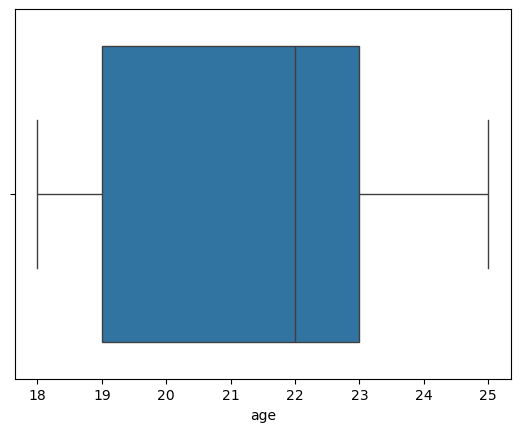

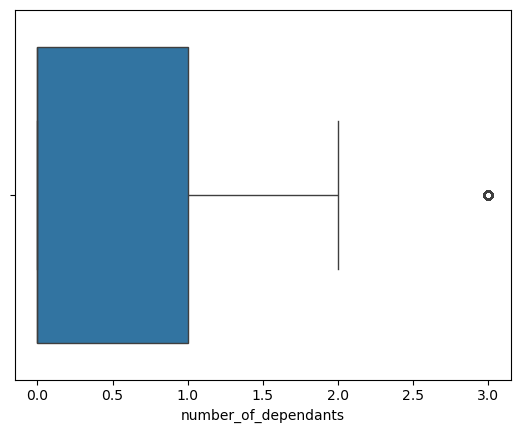

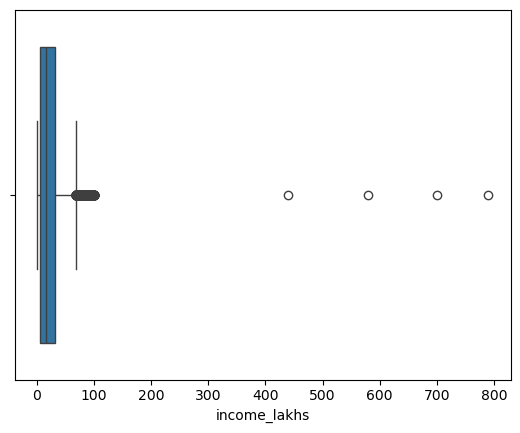

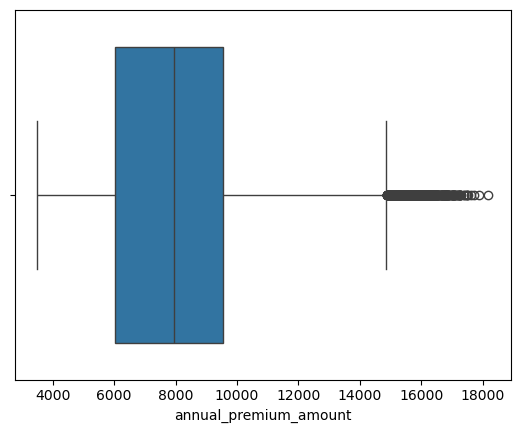

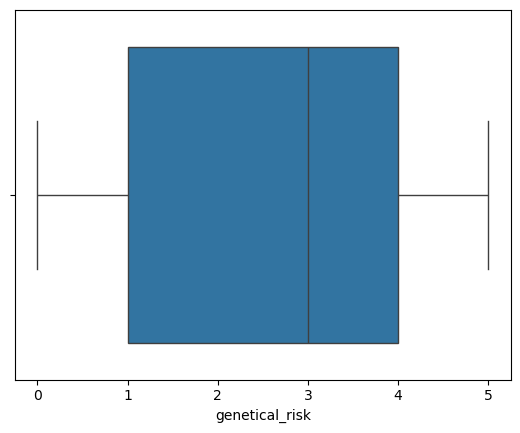

In [24]:
for col in numeric_columns:
    sns.boxplot(x = df[col])
    plt.show()

### Handling of outlier in age column

In [25]:
Q1 = np.percentile(df.age, 25)
Q3 = np.percentile(df.age, 75)
print(Q1)
print(Q3)
IQR = Q3 - Q1
UB = Q3 + 1.5 * IQR
print(UB)

19.0
23.0
29.0


In [26]:
df[df.age > 100].count()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [27]:
df[df.age > 100]['age'].unique()

array([], dtype=int64)

In [28]:
df[df.age > 100]['age'].value_counts()

Series([], Name: count, dtype: int64)

In [29]:
median_age = df.age.median()
print(median_age)

22.0


In [30]:
df.loc[df.age > 100, 'age'] = median_age

In [31]:
df[df.age > 100].count()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

### Handling outliers in income_lakhs column

In [32]:
Q1 = np.percentile(df.income_lakhs, 25)
Q3 = np.percentile(df.income_lakhs, 75)
print(Q1)
print(Q3)
IQR = Q3 - Q1
UB = Q3 + 1.5 * IQR
print(UB)

6.0
31.0
68.5


In [33]:
df[df.income_lakhs > 100].count()

age                      4
gender                   4
region                   4
marital_status           4
number_of_dependants     4
bmi_category             4
smoking_status           4
employment_status        4
income_level             4
income_lakhs             4
medical_history          4
insurance_plan           4
annual_premium_amount    4
genetical_risk           4
dtype: int64

In [34]:
df.shape

(20090, 14)

In [35]:
df[df.income_lakhs > 100]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
1677,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,440,No Disease,Silver,10636,3
4311,20,Female,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,> 40L,580,Thyroid,Silver,12888,5
4661,21,Female,Southwest,Unmarried,0,Obesity,No Smoking,Freelancer,> 40L,700,No Disease,Bronze,7424,3
6251,21,Female,Southeast,Unmarried,0,Normal,Occasional,Salaried,> 40L,790,No Disease,Silver,7586,0


In [36]:
# deleted the Outliers
df = df[df.income_lakhs <= 100]

In [37]:
df[df.income_lakhs > 100].count()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [38]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000
mean,21.494474,0.722742,22.390371,8141.799263,2.503883
std,2.294248,0.937238,21.732062,2749.912486,1.710184
min,18.000000,0.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.000000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,100.000000,18186.000000,5.000000


## EDA & Data Cleaning on Categorical variables

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20086 entries, 0 to 20095
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    20086 non-null  int64 
 1   gender                 20086 non-null  object
 2   region                 20086 non-null  object
 3   marital_status         20086 non-null  object
 4   number_of_dependants   20086 non-null  int64 
 5   bmi_category           20086 non-null  object
 6   smoking_status         20086 non-null  object
 7   employment_status      20086 non-null  object
 8   income_level           20086 non-null  object
 9   income_lakhs           20086 non-null  int64 
 10  medical_history        20086 non-null  object
 11  insurance_plan         20086 non-null  object
 12  annual_premium_amount  20086 non-null  int64 
 13  genetical_risk         20086 non-null  int64 
dtypes: int64(5), object(9)
memory usage: 2.3+ MB


In [40]:
categorical_columns = df.select_dtypes(include = "object").columns
categorical_columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [41]:
for col in categorical_columns:
    print(col, ":", df[col].unique())

gender : ['Male' 'Female']
region : ['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status : ['Regular' 'No Smoking' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status : ['Self-Employed' 'Freelancer' 'Salaried']
income_level : ['> 40L' '<10L' '10L - 25L' '25L - 40L']
medical_history : ['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan : ['Silver' 'Bronze' 'Gold']


In [42]:
df.smoking_status = df.smoking_status.replace({'Smoking=0' : 'No Smoking', 'Does Not Smoke' : 'No Smoking', 'Not Smoking' : 'No Smoking'})

C:\Users\Prikshit_Ishi\AppData\Local\Temp\ipykernel_22456\1074089374.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.smoking_status = df.smoking_status.replace({'Smoking=0' : 'No Smoking', 'Does Not Smoke' : 'No Smoking', 'Not Smoking' : 'No Smoking'})


In [43]:
df.smoking_status.unique()

array(['Regular', 'No Smoking', 'Occasional'], dtype=object)

# Step-2 : Feature Engineering

### convert the Categorical variable into Numerical variables

In [44]:
categorical_columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

### Ordinal Encoding: Rank or Order 'income_level', 'insurance_plan'

In [45]:
from sklearn.preprocessing import OrdinalEncoder

In [46]:
encoder = OrdinalEncoder(categories = [['Bronze', 'Silver', 'Gold']])
df.insurance_plan = encoder.fit_transform(df[['insurance_plan']])

C:\Users\Prikshit_Ishi\AppData\Local\Temp\ipykernel_22456\1274939803.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.insurance_plan = encoder.fit_transform(df[['insurance_plan']])


In [47]:
df.insurance_plan = df.insurance_plan.astype('int64')

C:\Users\Prikshit_Ishi\AppData\Local\Temp\ipykernel_22456\355962698.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.insurance_plan = df.insurance_plan.astype('int64')


In [48]:
df

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,1,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,1,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,1,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,0,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,0,5712,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20091,18,Female,Southeast,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,91,No Disease,2,11603,1
20092,23,Female,Northwest,Unmarried,0,Obesity,Occasional,Freelancer,> 40L,57,Diabetes,2,14498,2
20093,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,No Disease,0,9111,5
20094,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,No Disease,0,8564,4


In [49]:
encoder = OrdinalEncoder(categories = [['<10L', '10L - 25L', '25L - 40L', '> 40L']])
df.income_level = encoder.fit_transform(df[['income_level']])

C:\Users\Prikshit_Ishi\AppData\Local\Temp\ipykernel_22456\2938848440.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.income_level = encoder.fit_transform(df[['income_level']])


In [50]:
df

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,3.0,99,High blood pressure,1,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,0.0,3,No Disease,1,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,3.0,97,No Disease,1,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,1.0,15,No Disease,0,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,1.0,14,No Disease,0,5712,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20091,18,Female,Southeast,Unmarried,0,Underweight,No Smoking,Freelancer,3.0,91,No Disease,2,11603,1
20092,23,Female,Northwest,Unmarried,0,Obesity,Occasional,Freelancer,3.0,57,Diabetes,2,14498,2
20093,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,2.0,35,No Disease,0,9111,5
20094,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,2.0,32,No Disease,0,8564,4


# Use Label encoding to convert categorical column to numerical number

In [51]:
for col in categorical_columns:
    print(col, ":", df[col].unique())

gender : ['Male' 'Female']
region : ['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status : ['Regular' 'No Smoking' 'Occasional']
employment_status : ['Self-Employed' 'Freelancer' 'Salaried']
income_level : [3. 0. 1. 2.]
medical_history : ['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan : [1 0 2]


In [52]:
# Use label encoding when their is NO RANKING between the classes in the data

from sklearn.preprocessing import LabelEncoder

In [53]:
encoder = LabelEncoder()
df.region = encoder.fit_transform(df.region)

C:\Users\Prikshit_Ishi\AppData\Local\Temp\ipykernel_22456\166564218.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.region = encoder.fit_transform(df.region)


In [54]:
encoder = LabelEncoder()
df.bmi_category = encoder.fit_transform(df.bmi_category)

C:\Users\Prikshit_Ishi\AppData\Local\Temp\ipykernel_22456\744827222.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.bmi_category = encoder.fit_transform(df.bmi_category)


In [55]:
# One hot encoding: Convert categorical data to numerical
# When number of sub-categories are less
df = pd.get_dummies(df, columns = ['gender', 'marital_status', 'smoking_status', 'employment_status'], drop_first = True, dtype = int)

In [56]:
df

,age,region,number_of_dependants,bmi_category,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,gender_Male,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,0,2,3.0,99,High blood pressure,1,13365,4,1,1,0,1,0,1
1,22,1,0,3,0.0,3,No Disease,1,11050,3,0,1,0,0,0,0
2,21,2,0,0,3.0,97,No Disease,1,11857,4,0,1,0,1,1,0
3,25,2,0,0,1.0,15,No Disease,0,5684,2,1,1,0,0,0,0
4,20,2,2,2,1.0,14,No Disease,0,5712,1,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20091,18,2,0,3,3.0,91,No Disease,2,11603,1,0,1,0,0,0,0
20092,23,1,0,1,3.0,57,Diabetes,2,14498,2,0,1,1,0,0,0
20093,24,1,0,3,2.0,35,No Disease,0,9111,5,0,1,0,0,0,1
20094,21,1,0,0,2.0,32,No Disease,0,8564,4,1,1,0,1,0,0


# Covert categorical column to numerical : Manually

In [57]:
df.medical_history.unique()

array(['High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Diabetes & Heart disease',
       'Diabetes', 'Diabetes & Thyroid', 'Heart disease', 'Thyroid',
       'High blood pressure & Heart disease'], dtype=object)

In [58]:
risk_score = {
                'Diabetes' : 6,
                'High blood pressure' : 6,
                'Heart disease' : 8,
                'Thyroid' : 5,
                'No Disease' : 0,
                'Diabetes & High blood pressure' : 12,
                'High blood pressure & Heart disease' : 14,
                'Diabetes & Thyroid' : 11,
                'Diabetes & Heart disease' : 14
}
df.medical_history = df.medical_history.map(risk_score)

In [59]:
df

,age,region,number_of_dependants,bmi_category,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,gender_Male,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,0,2,3.0,99,6,1,13365,4,1,1,0,1,0,1
1,22,1,0,3,0.0,3,0,1,11050,3,0,1,0,0,0,0
2,21,2,0,0,3.0,97,0,1,11857,4,0,1,0,1,1,0
3,25,2,0,0,1.0,15,0,0,5684,2,1,1,0,0,0,0
4,20,2,2,2,1.0,14,0,0,5712,1,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20091,18,2,0,3,3.0,91,0,2,11603,1,0,1,0,0,0,0
20092,23,1,0,1,3.0,57,6,2,14498,2,0,1,1,0,0,0
20093,24,1,0,3,2.0,35,0,0,9111,5,0,1,0,0,0,1
20094,21,1,0,0,2.0,32,0,0,8564,4,1,1,0,1,0,0


# Feature Scaling

In [60]:
from sklearn.preprocessing import MinMaxScaler

In [61]:
df.columns

Index(['age', 'region', 'number_of_dependants', 'bmi_category', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount', 'genetical_risk', 'gender_Male',
       'marital_status_Unmarried', 'smoking_status_Occasional',
       'smoking_status_Regular', 'employment_status_Salaried',
       'employment_status_Self-Employed'],
      dtype='object')

In [62]:
cols_to_scale = ['age', 'region', 'number_of_dependants', 'bmi_category', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
      'gender_Male', 'marital_status_Unmarried',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed']

In [63]:
scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# Remove the features which are related to each other

# Correaltion matrix + Heatmap

In [64]:
cm = df.corr()

<Axes: >

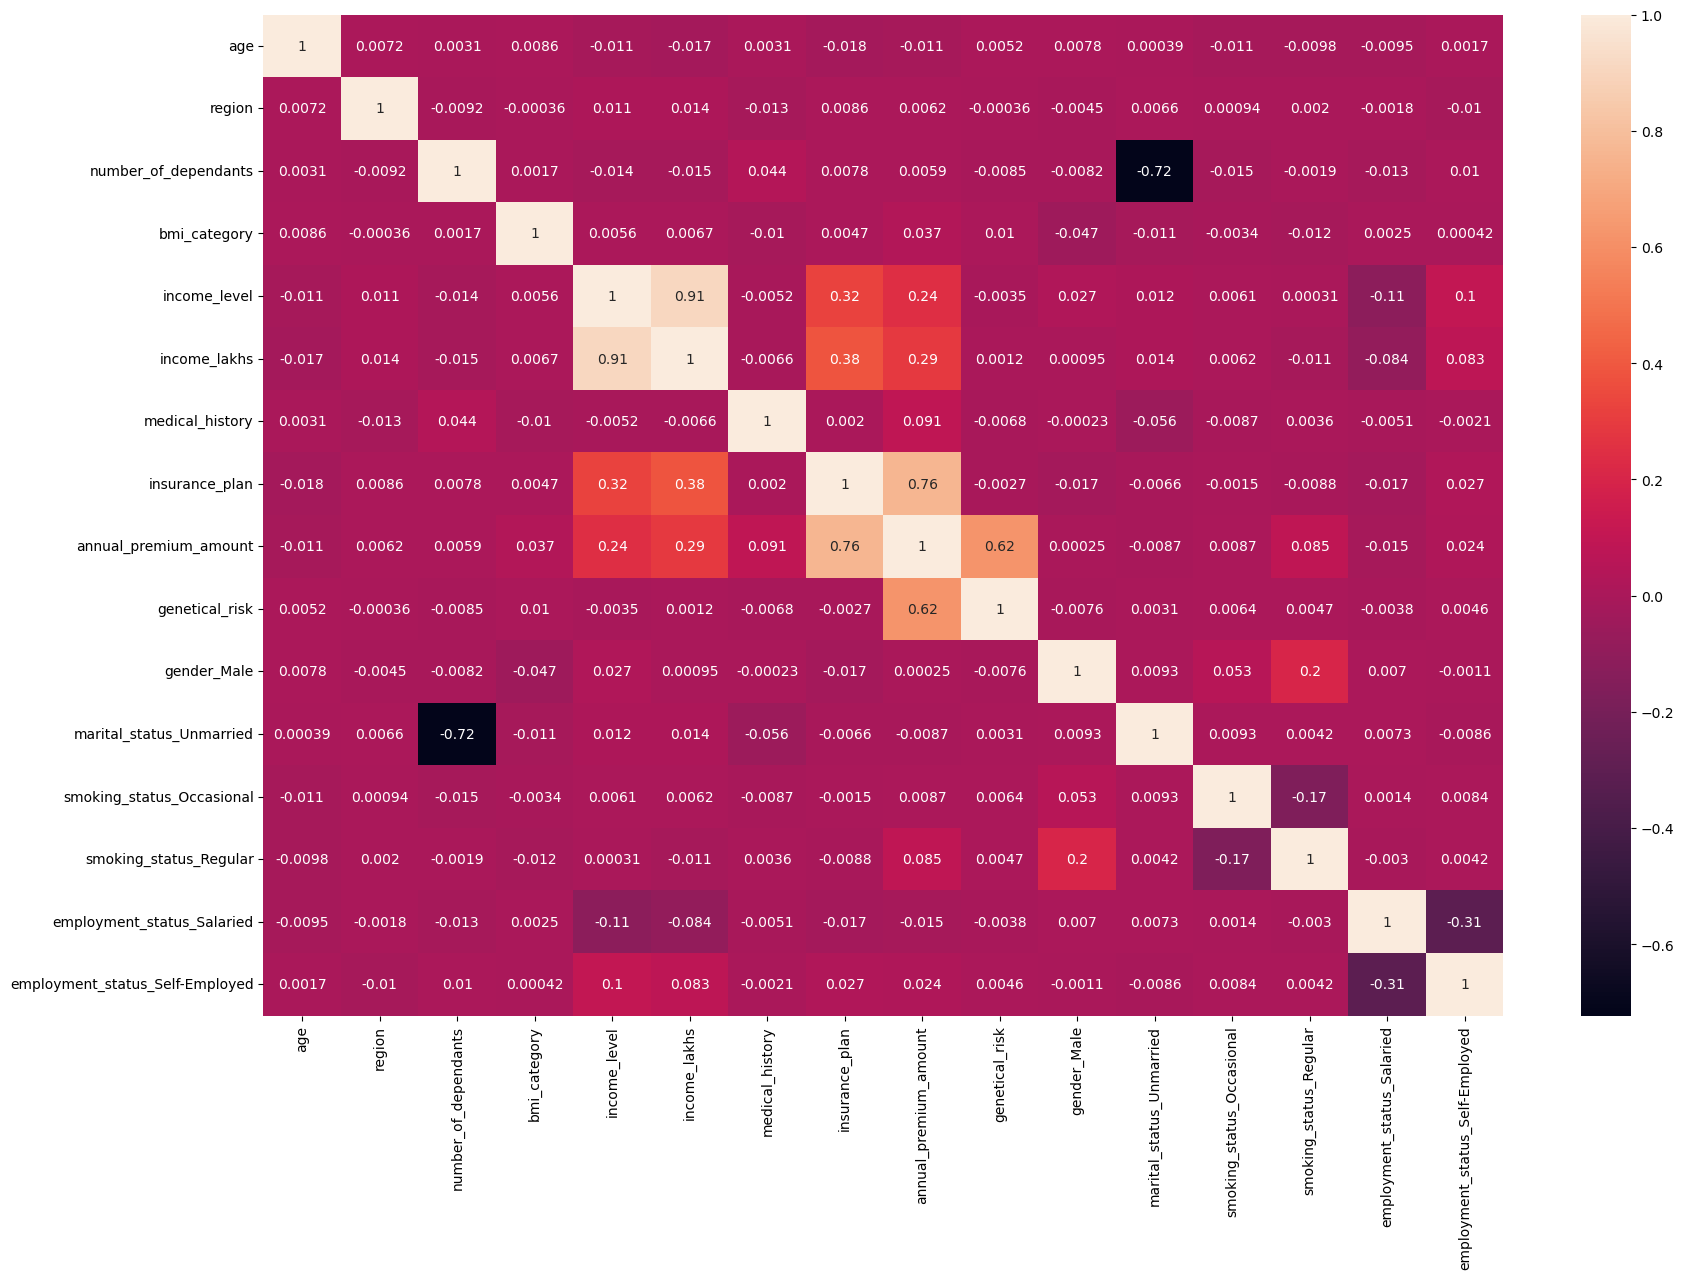

In [65]:
plt.figure(figsize = (20, 13))
sns.heatmap(cm, annot = True)

# Delete the highly correlated features : more than 80% related
 # number_of_dependents = marital_status_unmarried
# income_level = income_lakhs

# Don't delete the features which are related to target variable

In [66]:
df.drop(['marital_status_Unmarried', 'income_level'], axis = 1, inplace = True)

In [67]:
df.columns

Index(['age', 'region', 'number_of_dependants', 'bmi_category', 'income_lakhs',
       'medical_history', 'insurance_plan', 'annual_premium_amount',
       'genetical_risk', 'gender_Male', 'smoking_status_Occasional',
       'smoking_status_Regular', 'employment_status_Salaried',
       'employment_status_Self-Employed'],
      dtype='object')

# Step-4 : Model training & downloading/saving trained model

In [68]:
# Linear regresssion
# Xgboost

In [69]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [70]:
x = df.drop("annual_premium_amount", axis = 1)
y = df.annual_premium_amount

In [71]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

In [72]:
linear_obj = LinearRegression()
linear_obj.fit(x_train, y_train)

LinearRegression()

In [73]:
lr_score = linear_obj.score(x_test,y_test)
print(lr_score)

0.9832773367265416


In [74]:
# pip install --upgrade xgboost

In [75]:
import xgboost as xgb

In [76]:
XGB_obj = xgb.XGBRegressor()

In [77]:
# Hyper parameter tuning
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'n_estimators' : [20, 30, 40, 50],
    'learning_rate' : [0.001, 0.01, 0.1, 0.5],
    'max_depth' : [3,4,5,6]
}

random_search = RandomizedSearchCV(XGB_obj, param_grid, cv = 3)

random_search.fit(x_train,y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          learning_rate=None, max_bin=None,
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   param_distributions={'learning_rate': [0.001, 0.01, 0.1,
                                                          0.5],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [20, 30, 40, 50]})

In [78]:
random_search.best_score_

np.float64(0.9874313672383627)

In [79]:
# Target1: perfomance > 97%
# Target2: difference between actual premium and predicted premium < 10%

# Target2: difference between actual premium and predicted premium < 10%

In [80]:
y_pred = random_search.predict(x_test)
y_pred

array([7638.317 , 6480.9673, 4264.8535, ..., 6444.4937, 7172.7173,
       9498.488 ], dtype=float32)

In [81]:
residuals = y_pred - y_test
residual_pct = (residuals / y_test) * 100
print(residual_pct)

18375   -4.161645
18366    4.128652
19803   -0.955562
18517   -3.148277
106      4.012557
           ...   
16749   -1.248303
6197    -5.758128
11676    1.026707
15151   -0.847148
257      1.004767
Name: annual_premium_amount, Length: 4018, dtype: float64


In [82]:
result_df = pd.DataFrame({
                            'Actual' : y_test,
                            'Predicted' : y_pred,
                            'diff' : residuals,
                            'diff_pct' : residual_pct
})

In [83]:
result_df.head(10)

,Actual,Predicted,diff,diff_pct
18375,7970,7638.316895,-331.683105,-4.161645
18366,6224,6480.967285,256.967285,4.128652
19803,4306,4264.853516,-41.146484,-0.955562
18517,4768,4617.890137,-150.109863,-3.148277
106,5808,6041.049316,233.049316,4.012557
10678,9470,9621.895508,151.895508,1.603965
19028,9999,9676.529297,-322.470703,-3.225030
18455,6006,6041.049316,35.049316,0.583572
7947,11441,11845.750000,404.750000,3.537715
15180,8680,8517.151367,-162.848633,-1.876136


<Axes: xlabel='diff_pct', ylabel='Count'>

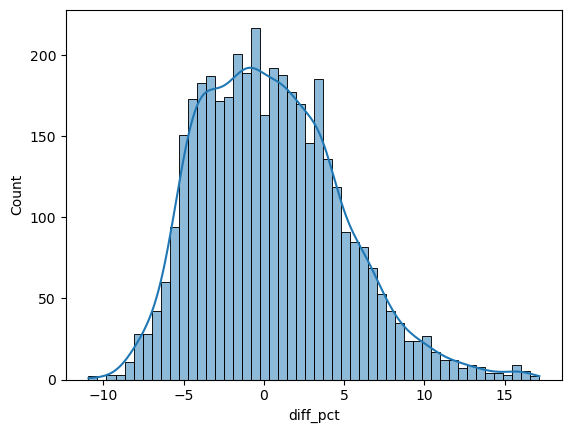

In [84]:
sns.histplot(result_df['diff_pct'], bins = 50, kde = True)

In [85]:
# extreme data 
extreame_result_df = result_df[np.abs(result_df.diff_pct > 10)]
extreame_result_df

,Actual,Predicted,diff,diff_pct
18951,3820,4314.432617,494.432617,12.943262
19897,3607,4193.502930,586.502930,16.260131
19816,4683,5191.446289,508.446289,10.857277
6214,4033,4617.890137,584.890137,14.502607
9898,3724,4106.338379,382.338379,10.266874
...,...,...,...,...
13258,4656,5186.786621,530.786621,11.400056
14978,4688,5191.446289,503.446289,10.739042
6552,3637,4193.502930,556.502930,15.301153
3205,3527,4101.974609,574.974609,16.302087


In [86]:
extreame_result_df.shape

(111, 4)

In [87]:
# Calculate percentage
x_test.shape

(4018, 13)

In [88]:
(1568 / 9994) * 100

15.689413648188912

In [89]:
# 3+ year experience ML engineer

# 5% values with more than 10% difference is allowed
# But we are getting 15% records having difference more than 10%

In [90]:
# Finding complete record where extreame values exist
extreame_error_df = x_test.loc[extreame_result_df.index]
extreame_error_df.head()

,age,region,number_of_dependants,bmi_category,income_lakhs,medical_history,insurance_plan,genetical_risk,gender_Male,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
18951,1.000000,0.666667,0.000000,1.0,0.202020,0.000000,0.0,0,0.0,1.0,0.0,0.0,1.0
19897,0.142857,0.666667,0.333333,1.0,0.080808,0.000000,0.0,0,1.0,0.0,0.0,0.0,1.0
19816,0.714286,0.000000,0.000000,1.0,0.191919,0.000000,0.0,1,1.0,0.0,0.0,1.0,0.0
6214,0.857143,0.333333,0.000000,1.0,0.080808,0.428571,0.0,0,1.0,0.0,0.0,1.0,0.0
9898,0.857143,1.000000,0.000000,0.0,0.101010,0.000000,0.0,0,1.0,0.0,0.0,1.0,0.0


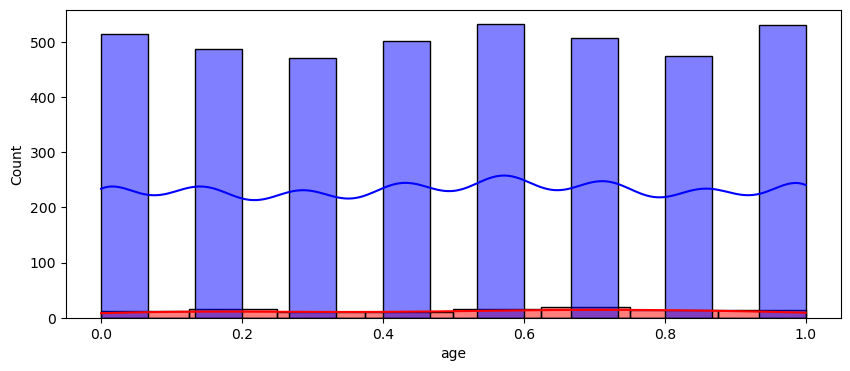

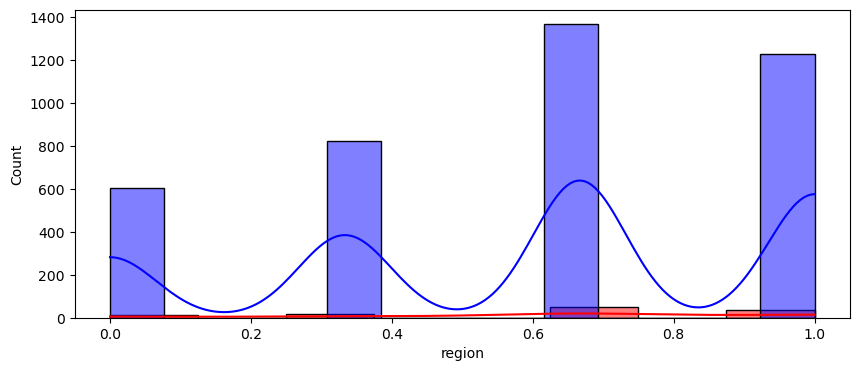

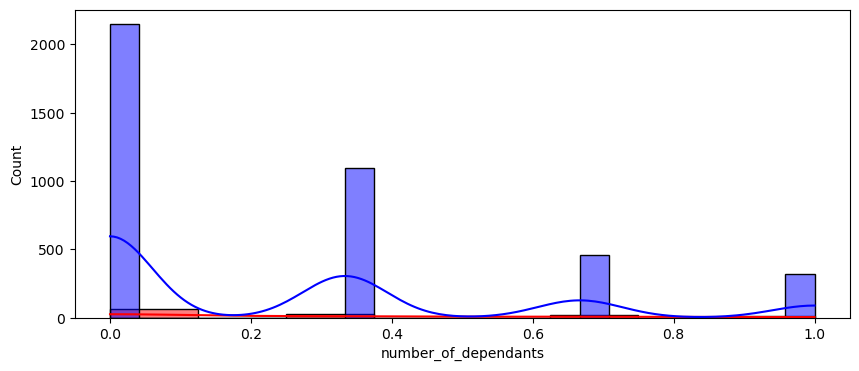

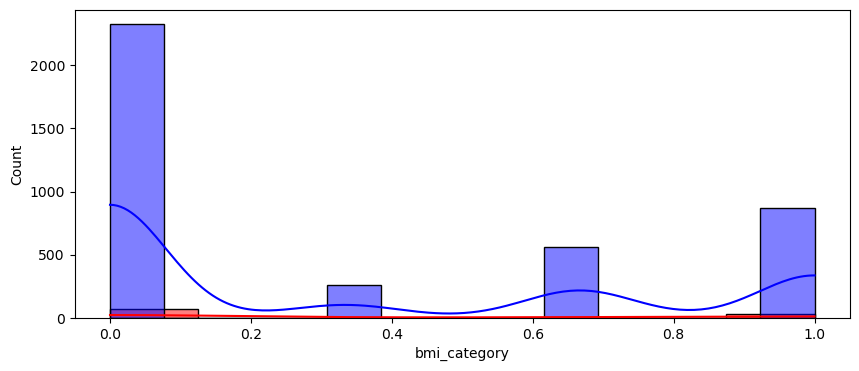

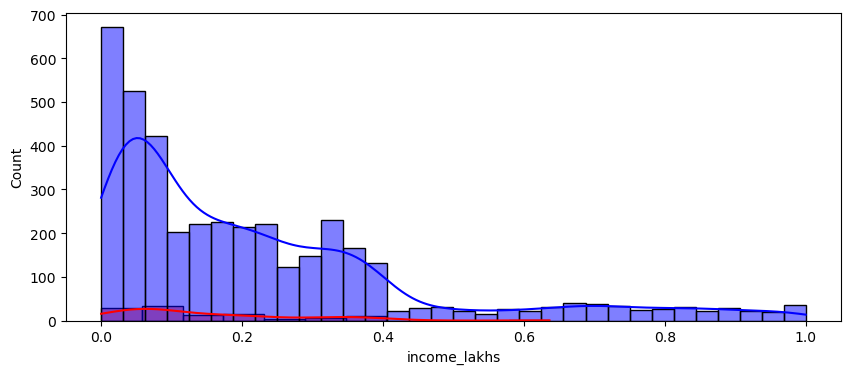

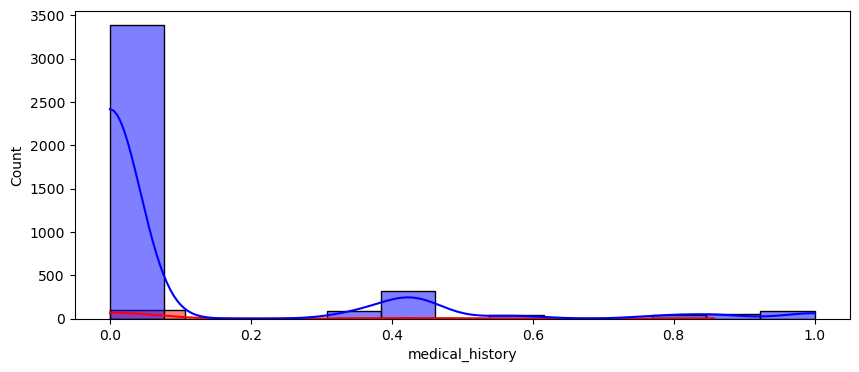

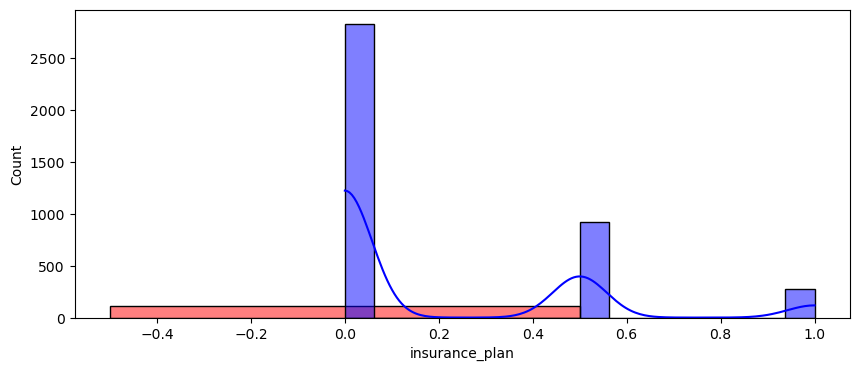

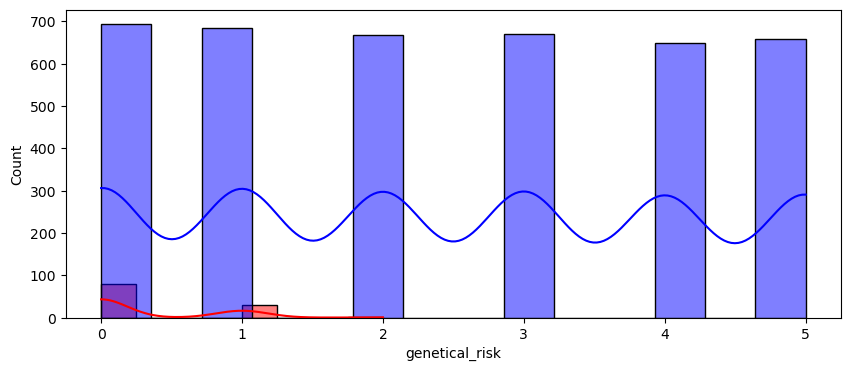

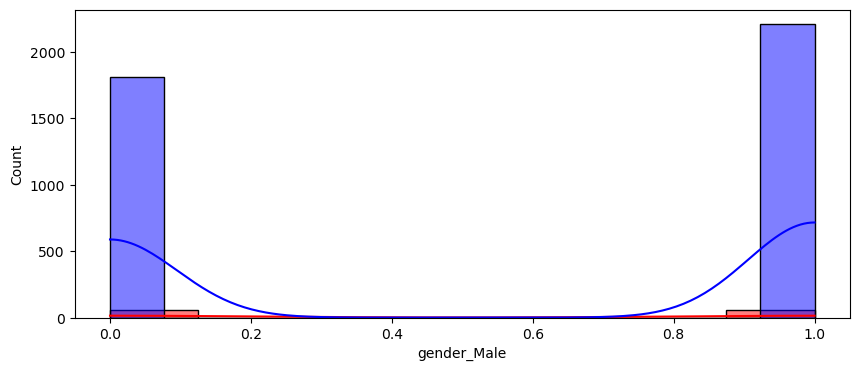

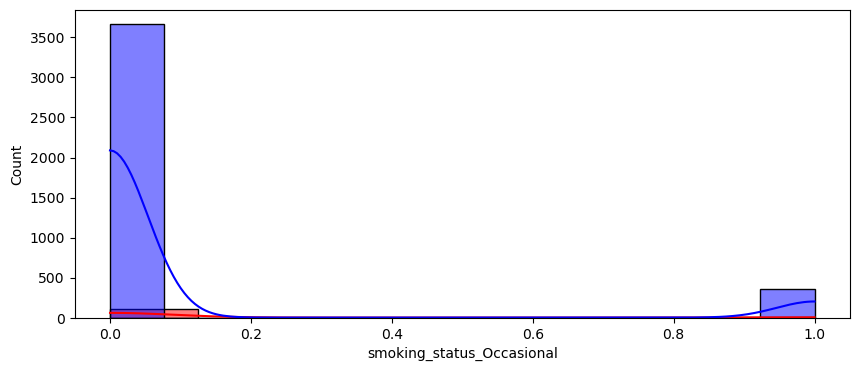

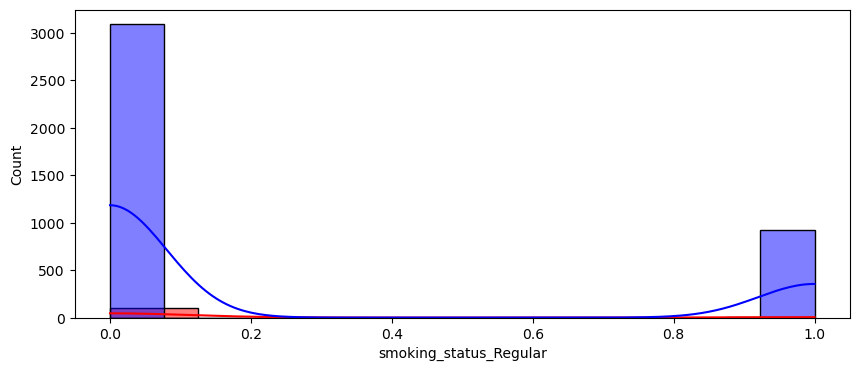

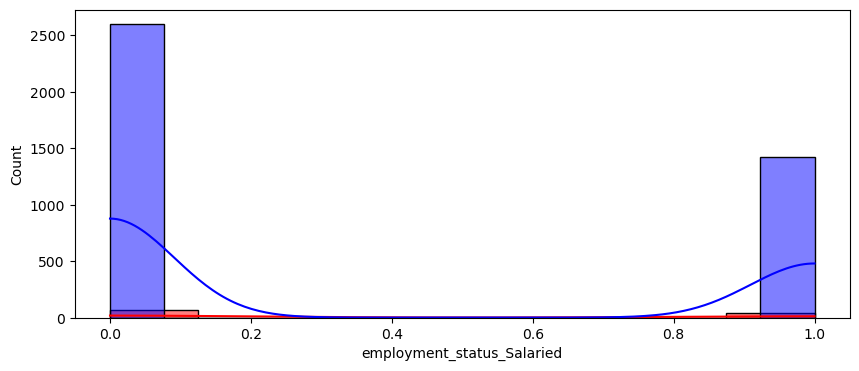

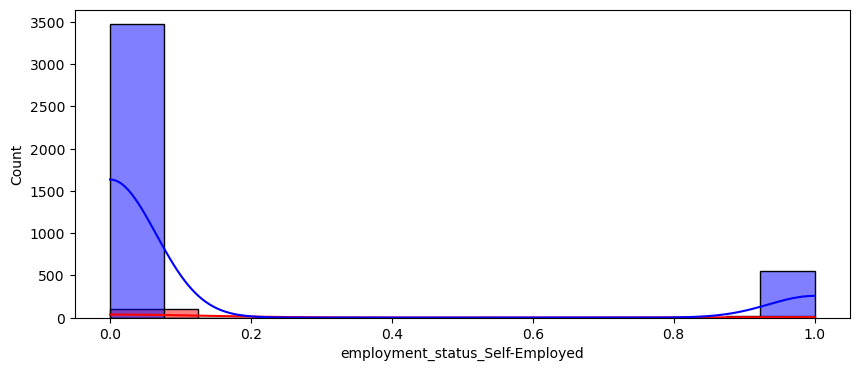

In [91]:
for feature in x_test.columns:
    plt.figure(figsize = (10,4))
    sns.histplot(extreame_error_df[feature], color = 'red', kde = True)
    sns.histplot(x_test[feature], color = 'blue', kde = True)
    plt.show()

In [92]:
x_test.shape

(4018, 13)

In [93]:
# reverse scaling
# Segmentation

# Reverse Scaling

In [94]:
# I want to find the actual value of features (not the scaled value)
# df.drop(['marital_status_Unmarried', 'income_level'], axis = 1, inplace = True)
df_reversed = pd.DataFrame()
extreame_error_df['income_level'] = -1
extreame_error_df['marital_status_Unmarried'] = -1
df_reversed[cols_to_scale] = scaler.inverse_transform(extreame_error_df[cols_to_scale])
df_reversed

,age,region,number_of_dependants,bmi_category,income_level,income_lakhs,medical_history,insurance_plan,gender_Male,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,25.0,2.0,0.0,3.0,-3.0,21.0,0.0,0.0,0.0,-1.0,1.0,0.0,0.0,1.0
1,19.0,2.0,1.0,3.0,-3.0,9.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,1.0
2,23.0,0.0,0.0,3.0,-3.0,20.0,0.0,0.0,1.0,-1.0,0.0,0.0,1.0,0.0
3,24.0,1.0,0.0,3.0,-3.0,9.0,6.0,0.0,1.0,-1.0,0.0,0.0,1.0,0.0
4,24.0,3.0,0.0,0.0,-3.0,11.0,0.0,0.0,1.0,-1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,20.0,2.0,2.0,3.0,-3.0,8.0,0.0,0.0,0.0,-1.0,0.0,0.0,1.0,0.0
107,25.0,3.0,0.0,3.0,-3.0,22.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0
108,20.0,2.0,1.0,3.0,-3.0,8.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0
109,21.0,2.0,1.0,0.0,-3.0,39.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0


In [95]:
x_test.columns

Index(['age', 'region', 'number_of_dependants', 'bmi_category', 'income_lakhs',
       'medical_history', 'insurance_plan', 'genetical_risk', 'gender_Male',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

In [96]:
# reverse scaling for actual test data

x_test_copy = x_test.copy()
df_test_reversed = pd.DataFrame()
x_test_copy['income_level'] = -1
x_test_copy['marital_status_Unmarried'] = -1
df_test_reversed[cols_to_scale] = scaler.inverse_transform(x_test_copy[cols_to_scale])
df_test_reversed

,age,region,number_of_dependants,bmi_category,income_level,income_lakhs,medical_history,insurance_plan,gender_Male,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,20.0,3.0,0.0,0.0,-3.0,21.0,0.0,0.0,0.0,-1.0,0.0,1.0,0.0,1.0
1,22.0,3.0,0.0,2.0,-3.0,28.0,0.0,0.0,0.0,-1.0,0.0,0.0,1.0,0.0
2,19.0,2.0,0.0,0.0,-3.0,8.0,0.0,0.0,1.0,-1.0,1.0,0.0,1.0,0.0
3,19.0,2.0,0.0,3.0,-3.0,4.0,6.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0
4,21.0,2.0,1.0,0.0,-3.0,11.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4013,22.0,3.0,0.0,0.0,-3.0,3.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0
4014,24.0,2.0,3.0,3.0,-3.0,31.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,1.0
4015,25.0,2.0,3.0,0.0,-3.0,2.0,6.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0
4016,20.0,2.0,1.0,0.0,-3.0,40.0,0.0,0.0,1.0,-1.0,1.0,0.0,0.0,0.0


<Axes: xlabel='age', ylabel='Count'>

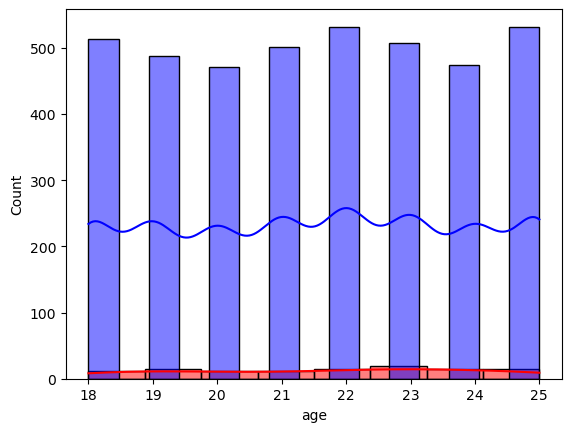

In [97]:
sns.histplot(df_reversed['age'], color= 'red', kde = True)
sns.histplot(df_test_reversed.age, color = 'blue', kde = True)

In [98]:
print((df_reversed.age <= 25).count())

111


In [99]:
# People below the age of 25 are unpredictable

In [100]:
# Solution-1: delete the entries below age 25
# Solution-2 : Segmentation 

# Segmenation: Divide the dataset into multiple sub-datasets and train them separatly.
    